In [14]:
import torch

# GPU 사용 가능 여부 확인
print(f"GPU 사용 가능 여부: {torch.cuda.is_available()}")

# 사용 가능한 GPU 개수 및 이름 확인
if torch.cuda.is_available():
    print(f"GPU 개수: {torch.cuda.device_count()}")
    print(f"현재 GPU 이름: {torch.cuda.get_device_name(0)}")

GPU 사용 가능 여부: True
GPU 개수: 4
현재 GPU 이름: NVIDIA TITAN Xp


In [15]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # 사용할 GPU 번호 입력
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import urllib.request
import zipfile
import glob
import os

# 경로 지정 
root='./'
image_folder_path = os.path.join(root, 'images') # 데이터 셋을 저장할 폴더 경로 생성 './images'

# images 폴더가 없으면 생성 
if not os.path.exists(image_folder_path):
    os.makedirs(image_folder_path)

# rps 데이터셋 다운로드 url 지정
url = 'https://storage.googleapis.com/download.tensorflow.org/data/rps.zip'
# url에서 파일을 다운로드하여, 'rps.zip'으로 저장
urllib.request.urlretrieve(url, 'rps.zip')
# 다운로드된 zip 파일 경로 변수에 저장
local_zip='rps.zip'

# 'images' 폴더에 압축 해제 
# with문 사용으로 작업 완료 후 파일 자동으로 닫힘
with zipfile.ZipFile(local_zip, 'r') as zip_ref: # rps.zip 파일을 '읽기 모드(r)'로 열기
    zip_ref.extractall(image_folder_path) # 열린 압축 파일 안의 모든 내용을 './images/' 폴더에 풀기

print(image_folder_path) # 데이터셋 저장 경로 출력
print(glob.glob(image_folder_path+'/rps/*')) # images/rps 폴더 안의 모든 폴더 목록 출력



./images
['./images/rps/rock', './images/rps/scissors', './images/rps/paper']


In [ ]:
import numpy as np
import torch 
from torch.utils.data import Dataset
from torchvision import datasets, transforms
# datasets : ImageFolder 등 이미지 데이터셋 도구 모음
# transforms : 이미지 전처리/변환 도구 

# image_folder_path : './images/'
image_folder = datasets.ImageFolder(
    root=image_folder_path + '/rps', # 데이터셋 경로 지정 -> './images/rps'
    # 여러 전처리를 순서대로 적용하는 파이프라인
    # PIL 이미지 -> Pytorch Tensor로 변환
    # 픽셀값 0~255 -> 0~1으로 정규화
    # 차원 순서(H,W,C) -> (C,H,W)로 변경
    transform= transforms.Compose([transforms.ToTensor(),]) 
    )

# 클래스 이름과 인덱스 매핑 출력 
# 폴더명을 알파벳 순으로 정렬하여 0부터 인덱스 부여
print(image_folder.class_to_idx)

{'paper': 0, 'rock': 1, 'scissors': 2}


In [ ]:
batch_size=32 # 한 번에 학습할 이미지 수 지정

# 전체 데이터셋(2520장)을 train/val/test로 분할
train_size = int(0.7*len(image_folder)) # 전체의 70%가 train 데이터셋 
val_size = int(0.15*len(image_folder)) # 전체의 15%가 validation 데이터셋
test_size = len(image_folder) - train_size - val_size # 전체의 15%가 test 데이터셋

# random_split : 데이터를 무작위로 섞어서 분할
# 클래스 편향 없이 paper/rock/scissors가 골구로 분배됨
train_dataset, val_dataset, test_dataset= torch.utils.data.random_split( 
    image_folder, # 분할할 원본 데이터셋
    [train_size, val_size, test_size] # 각 분할 크기 [1764, 378, 378]
    )

print(f"Train data 개수: {len(train_dataset)}") # 1764
print(f"Validation data 개수: {len(val_dataset)}") # 378
print(f"Test data 개수 : {len(test_dataset)}") #378

train_loader = torch.utils.data.DataLoader(
    train_dataset, # 학습용 데이터셋
    batch_size=batch_size, # 32장씩 불러옴
    shuffle=True, # 매 epoch마다 순서를 섞어 과적합을 방지
    num_workers=8 # 8개 CPU 프로세스로 병렬 데이터 로딩
    )
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=8)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=8)

# 1개 batch 추출
images, labels = next(iter(train_loader))

# images, labels에 각각 32개의 batch가 로드 
# images는 300x300 사이즈 RGB 이미지 32장이 1개 batch로 구성
print(images.shape)
print(labels.shape)

Train data 개수: 1764
Validation data 개수: 378
Test data 개수 : 378
torch.Size([32, 3, 300, 300])
torch.Size([32])


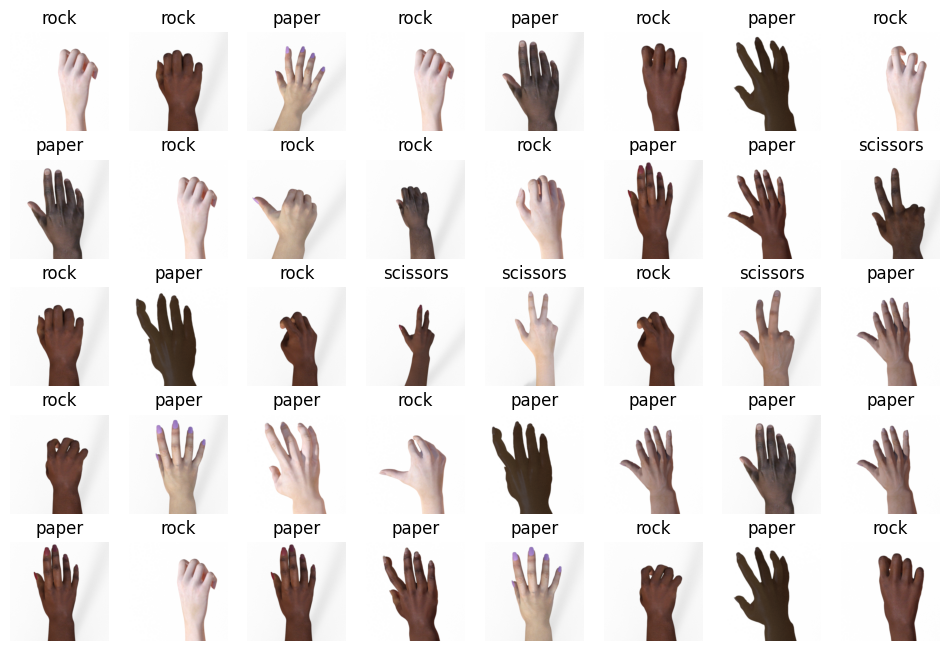

In [19]:
import matplotlib.pyplot as plt

# ImageFolder의 속성 값인 class_to_idx를 할당 
labels_map = {v:k for k,v in image_folder.class_to_idx.items()}

figure=plt.figure(figsize=(12,8))
cols, rows = 8,5

for i in range(1, cols*rows +1):
    sample_idx = torch.randint(len(images), size=(1,)).item()
    img, label = images[sample_idx], labels[sample_idx].item()
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(torch.permute(img, (1,2,0)))
plt.show()

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1, stride=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1, stride=1)
        self.fc1 = nn.Linear(64*75*75, 512)
        self.fc2 = nn.Linear(512,3)

    def forward(self,x):
        x=F.relu(self.conv1(x))
        x=F.max_pool2d(x,kernel_size=2, stride=2)
        x=F.relu(self.conv2(x))
        x=F.max_pool2d(x, kernel_size=2, stride=2)
        x=x.view(-1, 64*75*75)
        x=F.relu(self.fc1(x))
        x=self.fc2(x)
        return x

cnn = CNN().to(device)

In [23]:
# Parameters
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(cnn.parameters(), lr=0.001)


for epoch in range(30):
    # Train
    cnn.train()
    for index, (data,target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = cnn(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        if index%100==0:
            print("loss of {} epoch, {} index : {}".format(epoch, index, loss.item()))

    # Validation 
    cnn.eval()
    val_loss = 0
    val_correct =0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = cnn(data)
            val_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            val_correct += pred.eq(target.view_as(pred)).sum().item()
    
    print("Epoch {} | Val Loss: {:.4f} | Val Acc : {}/{} ({:.1f}%)".format(epoch, val_loss/len(val_loader), 
                                                                           val_correct, len(val_loader.dataset), 100. *val_correct/len(val_loader.dataset)))

loss of 0 epoch, 0 index : 0.6741677522659302
Epoch 0 | Val Loss: 0.1593 | Val Acc : 363/378 (96.0%)
loss of 1 epoch, 0 index : 0.17538253962993622
Epoch 1 | Val Loss: 0.1455 | Val Acc : 363/378 (96.0%)
loss of 2 epoch, 0 index : 0.18300659954547882
Epoch 2 | Val Loss: 0.1467 | Val Acc : 363/378 (96.0%)
loss of 3 epoch, 0 index : 0.08693121373653412
Epoch 3 | Val Loss: 0.1282 | Val Acc : 362/378 (95.8%)
loss of 4 epoch, 0 index : 0.12102721631526947
Epoch 4 | Val Loss: 0.1171 | Val Acc : 365/378 (96.6%)
loss of 5 epoch, 0 index : 0.09703268110752106
Epoch 5 | Val Loss: 0.1377 | Val Acc : 359/378 (95.0%)
loss of 6 epoch, 0 index : 0.07134168595075607
Epoch 6 | Val Loss: 0.1084 | Val Acc : 370/378 (97.9%)
loss of 7 epoch, 0 index : 0.04068916663527489
Epoch 7 | Val Loss: 0.1047 | Val Acc : 370/378 (97.9%)
loss of 8 epoch, 0 index : 0.08317146450281143
Epoch 8 | Val Loss: 0.0975 | Val Acc : 366/378 (96.8%)
loss of 9 epoch, 0 index : 0.09063924103975296
Epoch 9 | Val Loss: 0.0984 | Val Acc

In [24]:
cnn.eval()
test_loss = 0
correct=0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = cnn(data)
        test_loss += criterion(output, target).item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()

print("\nTest set : Average loss: {:.4f}, Accuracy : {}/{} ({:.0f}%)\n".format(
    test_loss/len(test_loader), correct, len(test_loader.dataset), 100. * correct/len(test_loader.dataset)
))


Test set : Average loss: 0.0717, Accuracy : 368/378 (97%)

